In [1]:
import os
import json
import joblib
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')

# 1. Initialize Repository Folder Structure
directories = [
    '../data/raw', '../data/processed', '../notebooks', '../src', 
    '../models', '../logs', '../outputs', '../configs', '../reports'
]
for directory in directories:
    os.makedirs(directory, exist_ok=True)
    
print("Project directory structure initialized!")

Project directory structure initialized!


## Project Structure Before Running the Notebook

Before running `project_implementation.ipynb`, the project has the following structure. Generated folders such as processed data, trained models, logs, reports, and output files are empty.

```text
churn-prediction/
├── configs/                    # Empty before execution
├── data/
│   ├── raw/
│   │   └── churn.csv          # Input dataset
│   └── processed/              # Empty before execution
├── logs/                       # Empty before execution
├── models/                     # Empty before execution
├── notebooks/
│   └── project_implementation.ipynb
├── outputs/                    # Empty before execution
├── reports/                    # Empty before execution
├── src/
│   ├── preprocess.py
│   ├── train.py
│   └── evaluate.py
├── tests/                      # Empty before execution
└── requirements.txt
```

The notebook creates the required directories during initialization. Later cells generate processed `.npy` files, preprocessing artifacts, the best model file, and false-positive/false-negative CSV files.

## 1. Load and Inspect Dataset

In [2]:
# Load the raw data
data_path = 'C:\\Users\\nagal\\OneDrive\\Desktop\\College\\Churn_Prediction\\data\\raw\\churn.csv' 
df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (7044, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Check target distribution
print("--- Churn Distribution ---")
print(df["Churn"].value_counts())

class_distribution = df["Churn"].value_counts(normalize=True) * 100
print("\n--- Churn Percentages ---")
print(class_distribution)

--- Churn Distribution ---
Churn
No     5175
Yes    1869
Name: count, dtype: int64

--- Churn Percentages ---
Churn
No     73.46678
Yes    26.53322
Name: proportion, dtype: float64


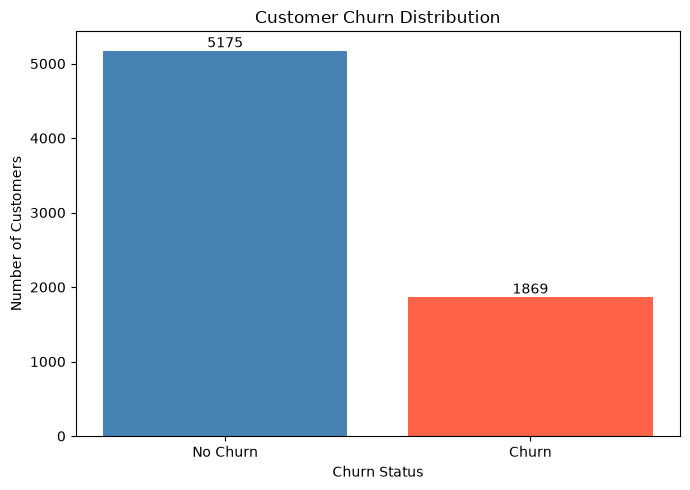

In [4]:
# Plot churn distribution
churn_counts = df["Churn"].value_counts()
churn_labels = ["No Churn", "Churn"]

plt.figure(figsize=(7, 5))
bars = plt.bar(churn_labels, churn_counts.values, color=["steelblue", "tomato"])

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 2. Preprocessing & Data Cleaning
Handling missing values, dropping redundant columns, and encoding the target variable.

In [5]:
blank_totalcharges = df[
    df["TotalCharges"].str.strip() == ""
]

In [6]:
blank_totalcharges

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [7]:
# Handle blank strings in TotalCharges by coercing to NaN and filling with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Drop redundant ID column
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# Encode Target Variable (Yes -> 1, No -> 0)
df['Churn'] = df['Churn'].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0) 

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn'] 

print("Data cleaning complete!")

Data cleaning complete!


## 3. Train-Test Split, Feature Engineering & Artifact Export
Splitting the data using stratification, applying scaling/encoding, and immediately saving the processed data and preprocessors to disk to prevent data loss.

In [8]:
# 1. Train-Test Split (Splitting first to avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Separate Column Types
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# 3. Scale Numerical Features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train[num_cols])
x_test_scaled = scaler.transform(X_test[num_cols])

# 4. One-Hot Encode Categorical Features
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
x_train_encoded = ohe.fit_transform(X_train[cat_cols])
x_test_encoded = ohe.transform(X_test[cat_cols])

# 5. Combine Features using np.hstack
X_train_final = np.hstack((x_train_scaled, x_train_encoded))
X_test_final = np.hstack((x_test_scaled, x_test_encoded))


# Save Processed Data Arrays 
np.save('../data/processed/X_train_final.npy', X_train_final)
np.save('../data/processed/X_test_final.npy', X_test_final)
np.save('../data/processed/y_train.npy', y_train.values) 
np.save('../data/processed/y_test.npy', y_test.values)

# Save Preprocessors
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(ohe, '../models/ohe.pkl')

# Generate and Save Metadata
metadata = {
    "dataset_name": "Telco Customer Churn",
    "train_shape": X_train_final.shape,
    "test_shape": X_test_final.shape,
    "numerical_features": list(num_cols),
    "categorical_features": list(cat_cols)
}
with open('../data/processed/dataset_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("Data split, engineered, and immediately saved to disk along with scaler, encoder, and metadata!")

Data split, engineered, and immediately saved to disk along with scaler, encoder, and metadata!


## 4. Baseline Model Development & Evaluation
Training Logistic Regression, Decision Tree, and Random Forest using balanced class weights.

In [9]:
def evaluate_and_store_metrics(model, name, X_test, y_test, results_dict, roc_dict):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] # Probabilities for the positive class (Churn=1)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f} ")
    print(f"F1-Score : {f1:.4f}\n")
    
    results_dict[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    
    # Store ROC data
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    roc_dict[name] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc}

## 5. Model Evaluation

Three classification models are trained and evaluated: Logistic Regression, Decision Tree, and Random Forest. Each model uses balanced class weights to account for the difference between customers who churn and those who do not.

The models are compared using the following metrics:

- **Accuracy:** The overall proportion of correct predictions.
- **Precision:** The proportion of predicted churn cases that are actual churn cases.
- **Recall:** The proportion of actual churn cases correctly identified.
- **F1-Score:** The balance between precision and recall.
- **ROC-AUC:** The model's ability to distinguish between churn and non-churn customers across classification thresholds.

Because identifying potential churners is the primary objective, the model with the highest **Recall** is selected as the best model. ROC-AUC curves and a confusion matrix are also generated to provide additional performance analysis.

In [10]:
metrics_results = {}
roc_data = {}

# Define Models using class_weight='balanced'
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
}

print("==========================================")
print("MODEL EVALUATION")
print("==========================================\n")

# Initialize tracking variables for the tournament
best_recall = 0
best_model_name = ""
best_model = None

for model_name, model in models.items():
    # Train and evaluate
    model.fit(X_train_final, y_train)
    evaluate_and_store_metrics(model, model_name, X_test_final, y_test, metrics_results, roc_data)
    
    # Programmatically compare results to find the best model based on Recall
    current_recall = metrics_results[model_name]['Recall']
    if current_recall > best_recall:
        best_recall = current_recall
        best_model_name = model_name
        best_model = model

# ==========================================
# MODEL EXPORT & ERROR ANALYSIS (TASK 2)
# ==========================================
print("==========================================")
print(f"Best Model: {best_model_name} (Recall: {best_recall:.4f})")
print("==========================================")

# Save the best model dynamically using its name
file_name = best_model_name.replace(" ", "_").lower()
joblib.dump(best_model, f'../models/{file_name}_baseline.pkl')
print(f"{best_model_name} serialized and saved to models folder!")

# Perform Error Analysis immediately using the dynamic best model
predictions = best_model.predict(X_test_final)
errors_df = X_test.copy()
errors_df['Actual_Churn'] = y_test
errors_df['Predicted_Churn'] = predictions

# Isolate errors
false_negatives = errors_df[(errors_df['Actual_Churn'] == 1) & (errors_df['Predicted_Churn'] == 0)]
false_positives = errors_df[(errors_df['Actual_Churn'] == 0) & (errors_df['Predicted_Churn'] == 1)]

false_negatives.to_csv('../outputs/false_negatives.csv', index=False)
false_positives.to_csv('../outputs/false_positives.csv', index=False)
print("Error analysis isolated and saved to outputs folder!")

MODEL EVALUATION

--- Logistic Regression ---
Accuracy : 0.7402
Precision: 0.5069
Recall   : 0.7888 
F1-Score : 0.6172

--- Decision Tree ---
Accuracy : 0.7161
Precision: 0.4792
Recall   : 0.7995 
F1-Score : 0.5992

--- Random Forest ---
Accuracy : 0.7559
Precision: 0.5276
Recall   : 0.7674 
F1-Score : 0.6253

Best Model: Decision Tree (Recall: 0.7995)
Decision Tree serialized and saved to models folder!
Error analysis isolated and saved to outputs folder!


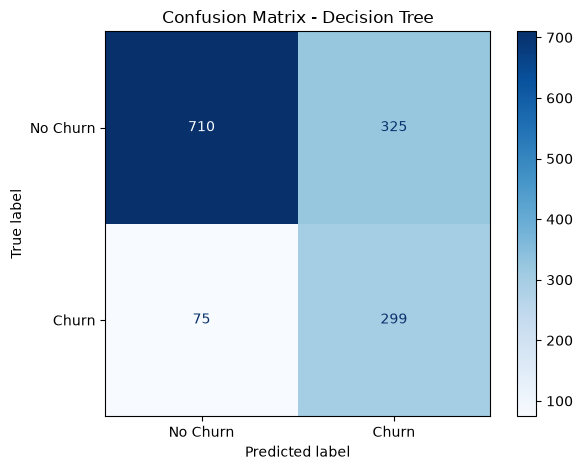

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues'
)

plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

## 6. ROC-AUC Curve Analysis

The Receiver Operating Characteristic (ROC) curve evaluates model performance across different classification thresholds.

- **False Positive Rate (FPR):** Proportion of non-churn customers incorrectly classified as churn.
- **True Positive Rate (TPR):** Proportion of churn customers correctly identified.
- **ROC-AUC:** Measures the model's ability to distinguish between churn and non-churn customers.

An AUC value closer to 1 indicates better classification performance, while an AUC of 0.5 represents random classification. The ROC curves below compare the performance of all trained models.import matplotlib.pyplot as plt

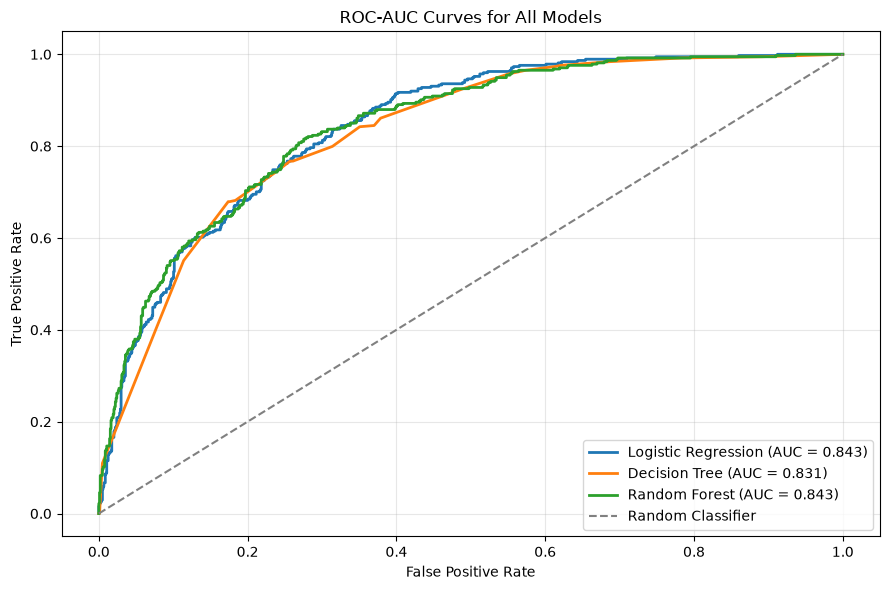

In [12]:
# Plot ROC-AUC curves for all trained models
plt.figure(figsize=(9, 6))

for model_name, roc_info in roc_data.items():
    plt.plot(
        roc_info['fpr'],
        roc_info['tpr'],
        linewidth=2,
        label=f"{model_name} (AUC = {roc_info['auc']:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curves for All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()